In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('data.csv')
df.head(5)
df.describe()
df.info()
nulos = df.isnull().sum()
porcentagem_nulos = (nulos / len(df)) * 100
print(
    f'\nNúmero de valores nulos por coluna:\n {nulos[nulos > 0]}'
    f'Porcentagem de valores nulos por coluna:\n {porcentagem_nulos[porcentagem_nulos > 0]}'
)


duplicadas = df.duplicated().sum()
print(f'Número de filas duplicadas: {duplicadas}')

idades_minimas = df['person_age'].min()
idades_maximas = df['person_age'].max()
print(f'Idade mínima: {idades_minimas}')
print(f'Idade máxima: {idades_maximas}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Número de valores nulos por co

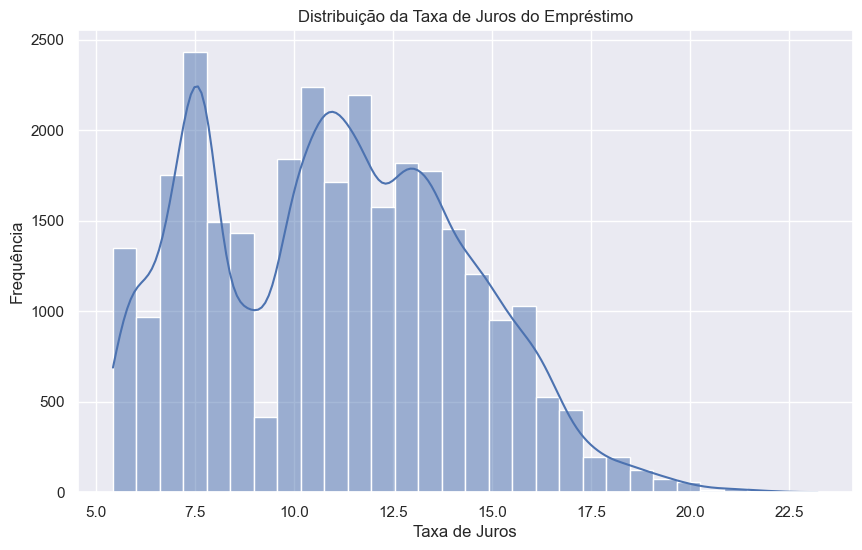

In [2]:
# como as duplicatas representam uma pequena porcentagem do total de registros e que é muito improvável que pessoas diferentes tenham exatamente os mesmos dados, vamos remover as duplicatas

df_tratado = df.drop_duplicates()

# antes de finalizar a limpeza, é interessante plotar alguns gráficos para buscar mais evidencias para justificar a substituição por media ou mediana no tratamento dos nulos.

#"Escolhi loan_int_rate porque é uma variável com aproximadamente 10% de valores ausentes.
#  Analisar sua distribuição ajudará a decidir a técnica mais adequada para imputação dos nulos (média ou mediana).
#  Além disso, trata-se de uma variável de interesse para análises posteriores,
#  como verificar se clientes inadimplentes tendem a receber empréstimos com taxas de juros diferentes."

sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))

sns.histplot(data=df_tratado, x='loan_int_rate', bins=30, kde=True)
plt.title('Distribuição da Taxa de Juros do Empréstimo')
plt.xlabel('Taxa de Juros')
plt.ylabel('Frequência')
plt.show()

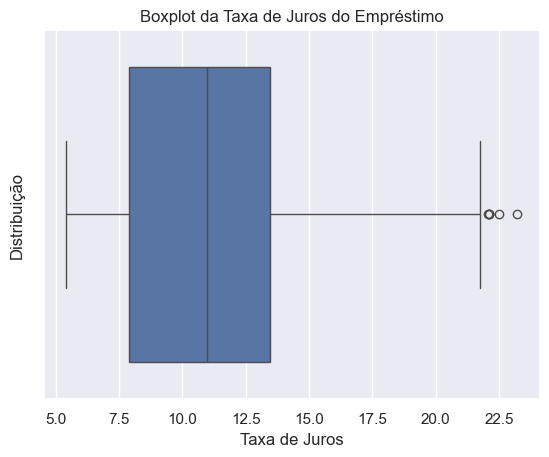

In [3]:
# O histograma sugere a existencia de outliers visualmente, mas para ter certeza precisamos usar o boxplot, que é uma ferramenta estatística mais robusta para identificar outliers.

sns.boxplot(x=df_tratado['loan_int_rate'])
plt.title('Boxplot da Taxa de Juros do Empréstimo')
plt.xlabel('Taxa de Juros')
plt.ylabel('Distribuição')
plt.show()

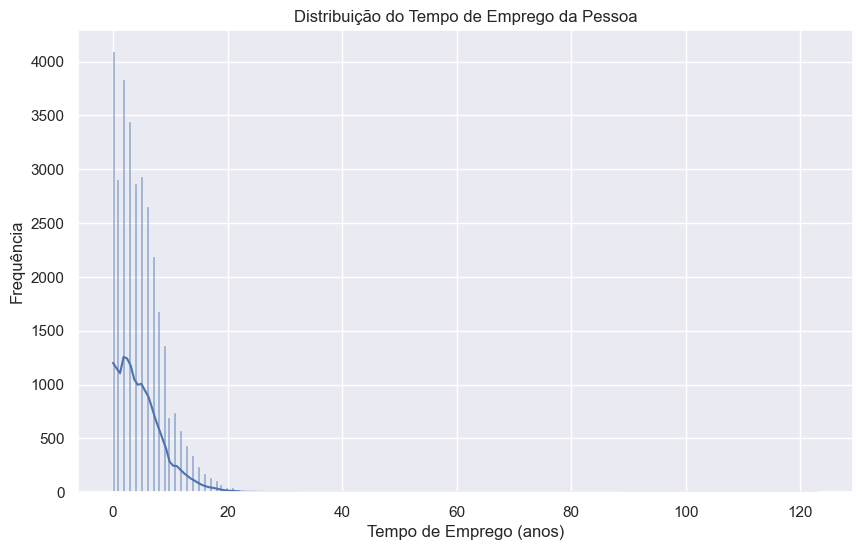

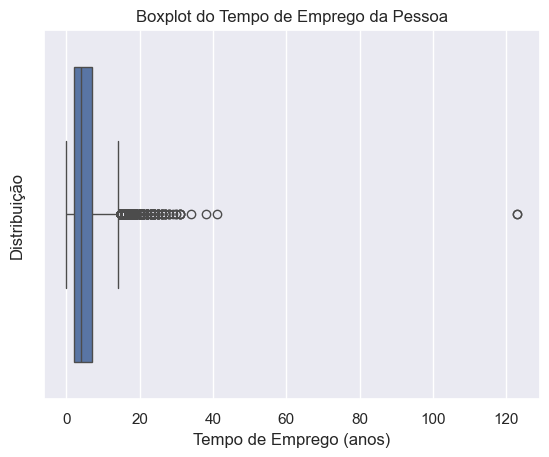

In [4]:
# agora, antes de tratar os dados nulos, vamos verificar outra variavel que possui dados nulos, a variável person_emp_length, que possui aproximadamente 20%
#  de valores ausentes. Analisar sua distribuição ajudará a decidir a técnica mais adequada para imputação dos nulos (média ou mediana).
# vamos gerar o histograma e o boxplot para a variável person_emp_length.

plt.figure(figsize=(10, 6))
sns.histplot(df_tratado['person_emp_length'], kde=True)
plt.title('Distribuição do Tempo de Emprego da Pessoa')
plt.xlabel('Tempo de Emprego (anos)')
plt.ylabel('Frequência')
plt.show()

sns.boxplot(x=df_tratado['person_emp_length'])
plt.title('Boxplot do Tempo de Emprego da Pessoa')
plt.xlabel('Tempo de Emprego (anos)')
plt.ylabel('Distribuição')
plt.show()

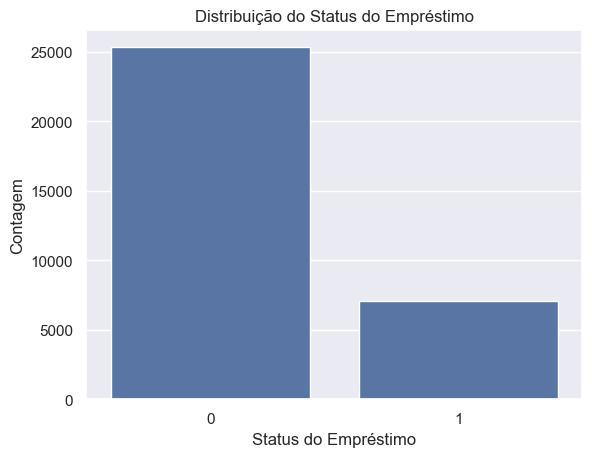

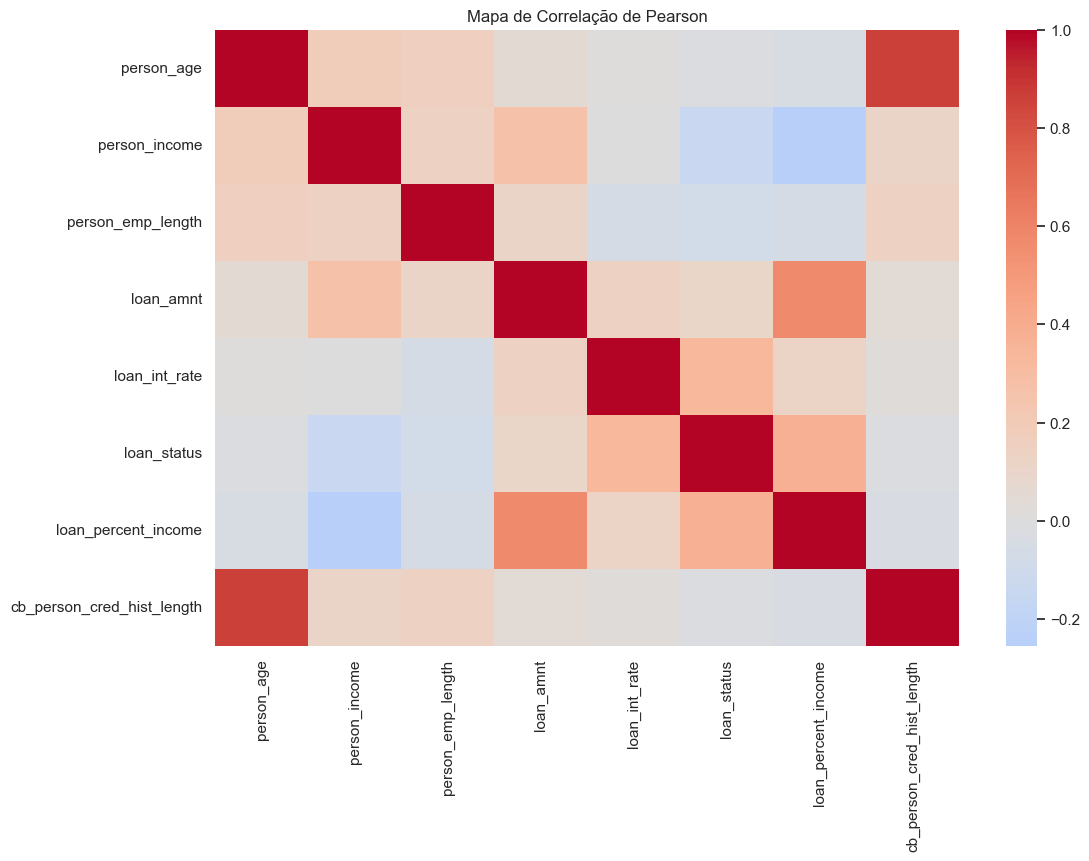

Duplicatas:
165
Valores nulos por coluna:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [5]:
#Confirmando a distribuição e balanceamento dos dados com um grafico de countplot para a variável loan_status, que é a variável alvo do nosso modelo de classificação.

sns.countplot(x='loan_status', data=df_tratado)
plt.title('Distribuição do Status do Empréstimo')
plt.xlabel('Status do Empréstimo')
plt.ylabel('Contagem')
plt.show()

# heatmap para verificar a correlação entre as variáveis numéricas do dataset, o que pode ajudar a identificar relações importantes entre as variáveis e a variável alvo.
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_tratado.corr(numeric_only=True),
    cmap='coolwarm',
    center=0
)

plt.title("Mapa de Correlação de Pearson")
plt.show()


#confirmando a quantidade de nulos e duplicatas antes de salvar o arquivo tratado.
print("Duplicatas:")
print(df.duplicated().sum())
print("Valores nulos por coluna:")
print(df.isnull().sum())

In [6]:
#Eliminando as duplicatas, substituindo os valores nulos pela mediana e salvando o arquivo tratado em um novo arquivo CSV.
df_tratado = df.copy()

df_tratado = df.drop_duplicates()
df_tratado = df_tratado.fillna(df_tratado.median(numeric_only=True))
df_tratado.to_csv('df_tratado.csv', index=False)

#confirmando que as duplicatas foram eliminadas e que não existem mais valores nulos no arquivo tratado.
print("Duplicatas:")
print(df_tratado.duplicated().sum())
print("Valores nulos por coluna:")
print(df_tratado.isnull().sum())

Duplicatas:
0
Valores nulos por coluna:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [7]:
#Criando uma variavel derivada que represente o risco de inadimplencia pelo comprometimento da renda do cliente.
df_tratado['financial_pressure'] = df_tratado['loan_int_rate'] * (df_tratado['loan_amnt'] / df_tratado['person_income'])
#df_tratado.head()

print(df_tratado[['loan_grade', 'cb_person_default_on_file']].head())
print(df_tratado['loan_grade'].unique())
print(df_tratado['cb_person_default_on_file'].unique())

  loan_grade cb_person_default_on_file
0          D                         Y
1          B                         N
2          C                         N
3          C                         N
4          C                         Y
['D' 'B' 'C' 'A' 'E' 'F' 'G']
['Y' 'N']


In [ ]:
# Fazendo o Encoding das variáveis:
# person_home_ownership -> One-Hot Encoding
# loan_intent -> One-Hot Encoding
# loan_grade -> Ordinal Encoding (A=0, B=1, ..., G=6)
# cb_person_default_on_file -> Label Encoding (N=0, Y=1)
df_tratado.reset_index(drop=True, inplace=True)
# One-Hot Encoding para variáveis categóricas nominal.
for col in ['person_home_ownership', 'loan_intent']:
    if col in df_tratado.columns:
        df_tratado = pd.get_dummies(df_tratado,drop_first=True, columns=[col], prefix=[col], dtype=int)

# Ordinal Encoding para loan_grade
grade_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
if 'loan_grade' in df_tratado.columns:
    df_tratado['loan_grade'] = df_tratado['loan_grade'].map(grade_mapping)

# Label Encoding para cb_person_default_on_file
if 'cb_person_default_on_file' in df_tratado.columns:
    df_tratado['cb_person_default_on_file'] = df_tratado['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

# Visualizando o resultado do dataframe após o encoding
print(df_tratado.head())
print(df_tratado.info())
print('\nColunas após o encoding:')
print(df_tratado.columns.tolist())

   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
0          22          59000              123.0           3      35000   
1          21           9600                5.0           1       1000   
2          25           9600                1.0           2       5500   
3          23          65500                4.0           2      35000   
4          24          54400                8.0           2      35000   

   loan_int_rate  loan_status  loan_percent_income  cb_person_default_on_file  \
0          16.02            1                 0.59                          1   
1          11.14            0                 0.10                          0   
2          12.87            1                 0.57                          0   
3          15.23            1                 0.53                          0   
4          14.27            1                 0.55                          1   

   cb_person_cred_hist_length  financial_pressure  \
0              

In [9]:
# Separação de treino e teste em x e y
from sklearn.model_selection import train_test_split

x = df_tratado.drop(columns=['loan_status'], axis=1)
y = df_tratado['loan_status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


print("Treino X:", x_train.shape)
print("Teste X:", x_test.shape)

print("\nTreino y:", y_train.shape)
print("Teste y:", y_test.shape)

y.value_counts(normalize=True)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)



Treino X: (25932, 18)
Teste X: (6484, 18)

Treino y: (25932,)
Teste y: (6484,)


loan_status
0    0.781308
1    0.218692
Name: proportion, dtype: float64

In [10]:
# Quantidade de amostras em y train

y_train.value_counts()


loan_status
0    20261
1     5671
Name: count, dtype: int64

In [11]:
import imblearn
#iniciando o balanceamento dos dados com a técnica SMOTE (Synthetic Minority Over-sampling Technique) para lidar com o desbalanceamento da variável alvo.

smote = imblearn.over_sampling.SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

# Quantidade de amostras em y train balanceado
y_train_balanced.value_counts()




loan_status
0    20261
1    20261
Name: count, dtype: int64

In [12]:
# lista de colunas contínuas para padronização
colunas_continuas = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'financial_pressure'
]

# Utilizando o StandardScaler somente nas variáveis dentro da lista para padronizar os dados,
# garantindo que todas as variáveis tenham a mesma escala e evitando que variáveis com valores maiores dominem o modelo.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Copia completa dos dataframes
x_train_balanced_scaled = x_train_balanced.copy()
x_test_scaled = x_test.copy()

# Substitui apenas as colunas contínuas pelos valores padronizados
x_train_balanced_scaled[colunas_continuas] = scaler.fit_transform(x_train_balanced[colunas_continuas])
x_test_scaled[colunas_continuas] = scaler.transform(x_test[colunas_continuas])

print(x_train_balanced_scaled.shape)
print(x_test_scaled.shape)
print(type(x_train_balanced_scaled))
print(type(x_test_scaled))

(40522, 18)
(6484, 18)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


k=3: Acurácia Treino=0.9337, Acurácia Teste=0.8287
k=5: Acurácia Treino=0.9129, Acurácia Teste=0.8288
k=7: Acurácia Treino=0.9020, Acurácia Teste=0.8270
k=9: Acurácia Treino=0.8936, Acurácia Teste=0.8273
k=11: Acurácia Treino=0.8887, Acurácia Teste=0.8259


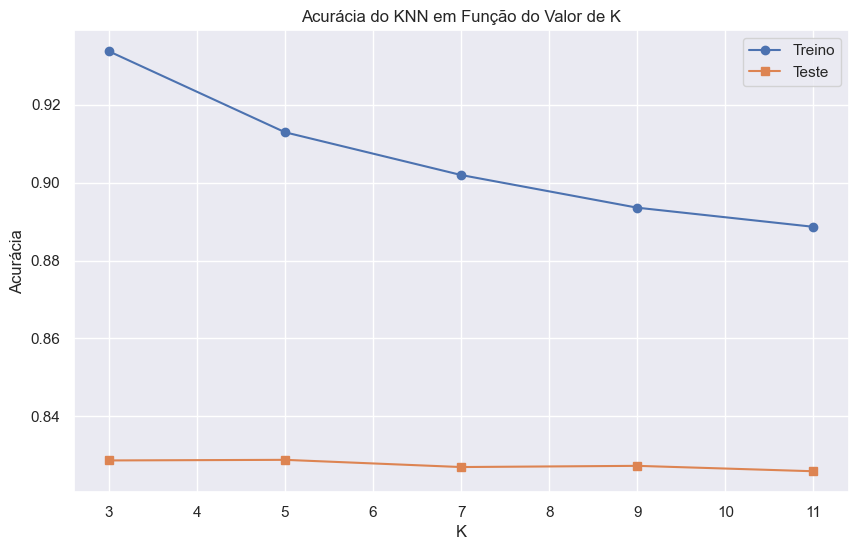

In [13]:
#KNN e Analise de Overfitting

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#Lista de valores de k para testar
k_values = [3, 5, 7, 9, 11]
results = []

#loop para testar diferentes valores de k e armazenar os resultados de acurácia para treino e teste
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_balanced_scaled, y_train_balanced)
    
    y_train_pred = knn.predict(x_train_balanced_scaled)
    y_test_pred = knn.predict(x_test_scaled)
    
    train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    results.append((k, train_accuracy, test_accuracy))

#Exibindo os resultados de acurácia para cada valor de k
for k, train_acc, test_acc in results:
    print(f'k={k}: Acurácia Treino={train_acc:.4f}, Acurácia Teste={test_acc:.4f}')

results_df = pd.DataFrame(
    results,
    columns=['K', 'Treino', 'Teste']
)

results_df

# grafico de linha para visualizar a acurácia de treino e teste em função do valor de k
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Treino'], marker='o', label='Treino')
plt.plot(results_df['K'], results_df['Teste'], marker='s', label='Teste')
plt.xlabel('K')
plt.ylabel('Acurácia')
plt.title('Acurácia do KNN em Função do Valor de K')
plt.legend()
plt.grid(True)
plt.show()

# K5 apresentou um resultado mais balanceado entre treino e teste.

   Max Depth  Train Accuracy  Test Accuracy  Difference
0        3.0        0.784784       0.830660   -0.045877
1        5.0        0.822837       0.865207   -0.042370
2        7.0        0.841197       0.891271   -0.050073
3        9.0        0.880707       0.889574   -0.008868
4       11.0        0.906224       0.877390    0.028833
5        NaN        1.000000       0.862276    0.137724


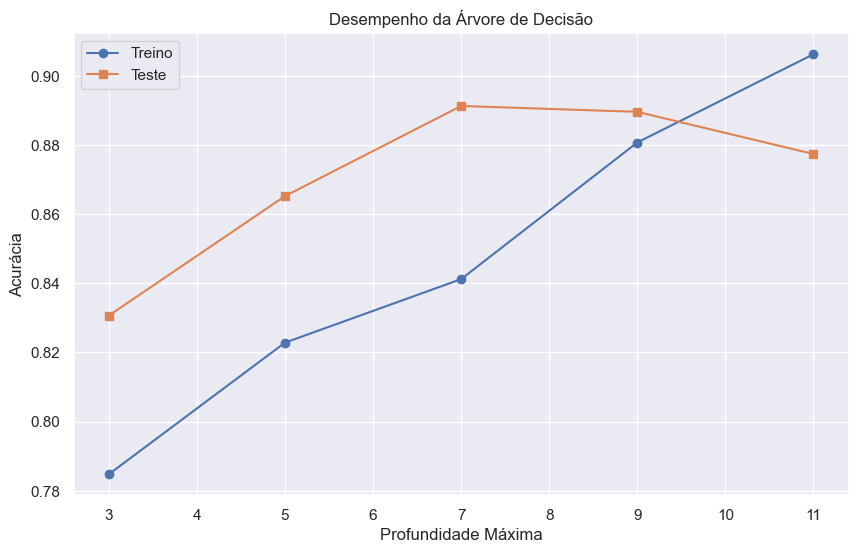

In [14]:
#Arvore de Decisão e Analise de Overfitting
from sklearn.tree import DecisionTreeClassifier

#lista de profundidades máximas para testar
max_depths = [3, 5, 7, 9, 11, None]
results_tree = []

# loop para testar diferentes profundidades máximas e armazenar os resultados de acurácia para treino e teste
for depth in max_depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(x_train_balanced, y_train_balanced)
    
    y_train_pred_tree = tree.predict(x_train_balanced)
    y_test_pred_tree = tree.predict(x_test)
    
    train_accuracy_tree = accuracy_score(y_train_balanced, y_train_pred_tree)
    test_accuracy_tree = accuracy_score(y_test, y_test_pred_tree)
    
    results_tree.append((depth, train_accuracy_tree, test_accuracy_tree))

results_tree_df = pd.DataFrame(
    results_tree,
    columns=['Max Depth', 'Train Accuracy', 'Test Accuracy']
)

results_tree_df['Difference'] = (
    results_tree_df['Train Accuracy'] -
    results_tree_df['Test Accuracy']
)

print(results_tree_df)

# grafico de linha para visualizar a acurácia de treino e teste em função da profundidade máxima da árvore
plt.figure(figsize=(10, 6))
plt.plot(results_tree_df['Max Depth'], results_tree_df['Train Accuracy'], marker='o', label='Treino')
plt.plot(results_tree_df['Max Depth'], results_tree_df['Test Accuracy'], marker='s', label='Teste')
plt.xlabel('Profundidade Máxima')
plt.ylabel('Acurácia')
plt.title('Desempenho da Árvore de Decisão')
plt.legend()
plt.grid(True)
plt.show()

# A profundidade máxima de 7 apresentou um resultado mais balanceado entre treino e teste, com a maior acurácia e diferença treino/teste aceitável.

Acurácia do modelo final de Árvore de Decisão: 0.8913
Acurácia do modelo final de KNN: 0.8288


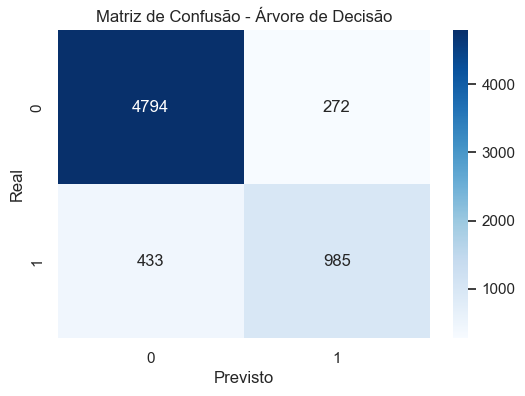

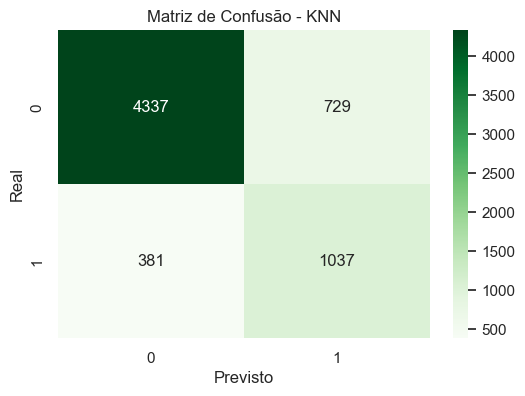


Relatório de classificação - Árvore de Decisão
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      5066
           1       0.78      0.69      0.74      1418

    accuracy                           0.89      6484
   macro avg       0.85      0.82      0.83      6484
weighted avg       0.89      0.89      0.89      6484


Relatório de classificação - KNN
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      5066
           1       0.59      0.73      0.65      1418

    accuracy                           0.83      6484
   macro avg       0.75      0.79      0.77      6484
weighted avg       0.85      0.83      0.84      6484



In [15]:
# Agora vamos treinar o modelo final de árvore de decisão e do KNN e depois usar a matriz de confusão para avaliar o desempenho dos modelos e comparar os resultados.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Modelo final de Árvore de Decisão
tree_final = DecisionTreeClassifier(max_depth=7, random_state=42)
tree_final.fit(x_train_balanced, y_train_balanced)
tree_final_pred = tree_final.predict(x_test)
tree_final_accuracy = accuracy_score(y_test, tree_final_pred)
print(f'Acurácia do modelo final de Árvore de Decisão: {tree_final_accuracy:.4f}')

# Modelo final de KNN
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(x_train_balanced_scaled, y_train_balanced)
knn_final_pred = knn_final.predict(x_test_scaled)
knn_final_accuracy = accuracy_score(y_test, knn_final_pred)
print(f'Acurácia do modelo final de KNN: {knn_final_accuracy:.4f}')

# Matriz de confusão para a Árvore de Decisão
cm_tree = confusion_matrix(y_test, tree_final_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# Matriz de confusão para o KNN
cm_knn = confusion_matrix(y_test, knn_final_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# Relatórios de classificação
print('\nRelatório de classificação - Árvore de Decisão')
print(classification_report(y_test, tree_final_pred))

print('\nRelatório de classificação - KNN')
print(classification_report(y_test, knn_final_pred))

Embora a Árvore de Decisão tenha apresentado maior acurácia geral e maior precisão, optei por recomendar o modelo KNN devido ao seu maior recall para a classe de inadimplentes (0,73 contra 0,69 da Árvore). Em uma instituição financeira, considero que o custo de um falso negativo é significativamente maior, pois representa a concessão de crédito a um cliente que poderá não quitar sua dívida. Já um falso positivo não implica necessariamente na recusa do empréstimo, podendo resultar apenas em uma análise complementar, exigência de garantias ou aplicação de taxas de juros mais elevadas. Dessa forma, prefiro um modelo que identifique um número maior de clientes de risco, mesmo ao custo de uma redução na precisão e na acurácia geral.